# Mushroom Classifier
This model's goal is to classify images of mushrooms and determine whether they are poisonous or safe.  
The model was trained with an AMD GPU, which caused a fair amount of issues and forced some architecture changes.

In [1]:
import os
os.environ["KERAS_BACKEND"] = "tensorflow"
os.environ["CUDA_VISIBLE_DEVICES"] = "1"

import keras
from keras import layers

import numpy as np
import matplotlib.pyplot as plt

from keras import backend as K
import tensorflow as tf

# Verification block
print(f"Keras version: {keras.__version__}")
print(f"TensorFlow version: {tf.__version__}")

# This will list your DirectML adapters (GPU:0 and GPU:1)
gpus = tf.config.list_physical_devices('GPU')
print(f"GPUs Detected: {gpus}")

C:\Users\Omistaja\anaconda3\envs\tf_directml\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


Keras version: 2.10.0
TensorFlow version: 2.10.0
GPUs Detected: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


Performing data augmentation while the Jupyter server was running always crashed the kernel during training phase.  
To fix this, the entire dataset is augmented at once and saved as a new dataset.  
This means that the images are already augmented when loaded as a dataset.

In [2]:
from sklearn.model_selection import train_test_split
batch_size_n = 64
img_size = (224, 224)

# Load images
train_dataset = keras.utils.image_dataset_from_directory(
    '../datasets/mushroom_augmented/train',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    labels='inferred',
    label_mode='int',
    shuffle=True,
    seed=123)

test_dataset = keras.utils.image_dataset_from_directory(
    '../datasets/mushroom_augmented/test',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    labels='inferred',
    label_mode='int',
    seed=123)

val_dataset = keras.utils.image_dataset_from_directory(
    '../datasets/mushroom_augmented/val',
    batch_size=batch_size_n, 
    image_size=img_size,
    crop_to_aspect_ratio=True,
    labels='inferred',
    label_mode='int',
    seed=123)

num_classes = len(train_dataset.class_names)
class_names = train_dataset.class_names

Found 17417 files belonging to 9 classes.
Found 1015 files belonging to 9 classes.
Found 1002 files belonging to 9 classes.


The total dataset is now much larger than the original, because of the preprocessed images.

In [3]:
# Prefetch datasets to improve performance
import tensorflow as tf
AUTOTUNE = tf.data.AUTOTUNE

train_dataset = train_dataset.cache().prefetch(buffer_size=AUTOTUNE)
val_dataset = val_dataset.cache().prefetch(buffer_size=AUTOTUNE)
test_dataset = test_dataset.cache().prefetch(buffer_size=AUTOTUNE)

In [4]:
from keras import Sequential
from keras import layers
from keras.optimizers import Adam

## CNN model (custom)
This model is a convolutional network that will be fully trained from the ground up on this dataset.

In [5]:
model = Sequential([
    layers.Input(shape=(224, 224, 3)),
    layers.Rescaling(1./255),
    
    layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),
    
    layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3, 3), activation='relu', padding='same'),
    layers.GlobalAveragePooling2D(), # Or layers.Flatten() for more parameters
    
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(num_classes, activation='softmax')
])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 rescaling (Rescaling)       (None, 224, 224, 3)       0         
                                                                 
 conv2d (Conv2D)             (None, 224, 224, 32)      896       
                                                                 
 max_pooling2d (MaxPooling2D  (None, 112, 112, 32)     0         
 )                                                               
                                                                 
 conv2d_1 (Conv2D)           (None, 112, 112, 64)      18496     
                                                                 
 max_pooling2d_1 (MaxPooling  (None, 56, 56, 64)       0         
 2D)                                                             
                                                                 
 conv2d_2 (Conv2D)           (None, 56, 56, 128)       7

In [6]:
model.compile(optimizer=Adam(learning_rate = 0.0001), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [7]:
from keras.callbacks import EarlyStopping

history = model.fit(
    train_dataset,
    batch_size=batch_size_n,
    epochs=64,
    validation_data=val_dataset,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/64
273/273 [==============================] - 10s 34ms/step - loss: 2.0600 - accuracy: 0.2163 - val_loss: 1.9805 - val_accuracy: 0.2335
Epoch 2/64
273/273 [==============================] - 8s 28ms/step - loss: 1.9642 - accuracy: 0.2345 - val_loss: 1.9104 - val_accuracy: 0.2715
Epoch 3/64
273/273 [==============================] - 8s 28ms/step - loss: 1.8956 - accuracy: 0.2808 - val_loss: 1.8555 - val_accuracy: 0.2994
Epoch 4/64
273/273 [==============================] - 8s 28ms/step - loss: 1.8546 - accuracy: 0.3053 - val_loss: 1.8153 - val_accuracy: 0.3144
Epoch 5/64
273/273 [==============================] - 8s 28ms/step - loss: 1.8172 - accuracy: 0.3313 - val_loss: 1.7829 - val_accuracy: 0.3303
Epoch 6/64
273/273 [==============================] - 8s 28ms/step - loss: 1.7881 - accuracy: 0.3493 - val_loss: 1.7605 - val_accuracy: 0.3413
Epoch 7/64
273/273 [==============================] - 8s 28ms/step - loss: 1.7576 - accuracy: 0.3658 - val_loss: 1.7375 - val_accuracy: 0.350

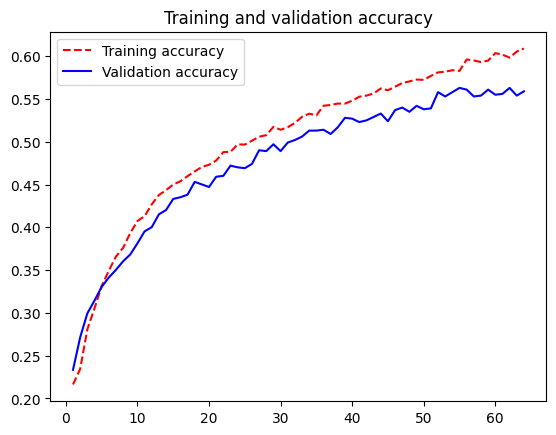

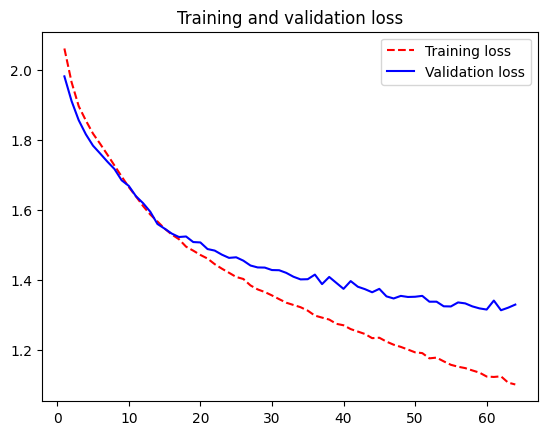

In [8]:
acc = history.history["accuracy"]
val_acc = history.history["val_accuracy"]
loss = history.history["loss"]
val_loss = history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [9]:
test_loss, test_acc = model.evaluate(test_dataset)
val_loss, val_acc = model.evaluate(val_dataset)
print("Test accuracy:", test_acc)
print("Validation accuracy:", val_acc)

16/16 [==============================] - 0s 9ms/step - loss: 1.3300 - accuracy: 0.5589
Test accuracy: 0.5458128452301025
Validation accuracy: 0.5588822364807129


The baseline for the current model is ~57%, with slight variations on each training run.  
Mushrooms are very complex structures, which means that this model needs to learn to sort through a lot of parameters.  
Pretrained models should be better at this task. The next cells compare the performance of EfficientNet and MobileNetV2.

In [10]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

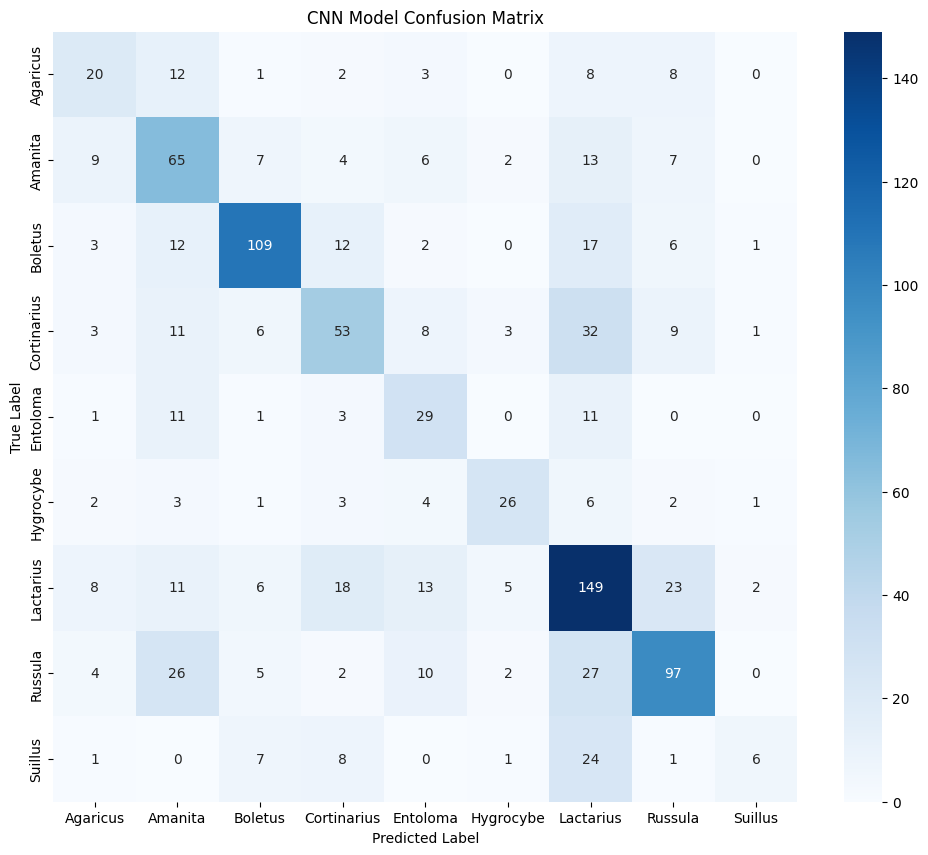

In [11]:
# 2. Create the matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot using Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('CNN Model Confusion Matrix')
plt.show()

## MobileNetV2 Model

In [12]:
import tensorflow as tf
from keras.applications import MobileNetV2
from keras import Sequential
from keras import layers
from keras.optimizers import Adam

conv_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

conv_base.trainable = False

In [13]:
from keras.optimizers import Adam
from keras.applications.mobilenet_v2 import preprocess_input

inputs = layers.Input(shape=(224, 224,3))
x = preprocess_input(inputs)
x = conv_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = keras.Model(inputs, outputs)

model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_3 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 tf.math.truediv (TFOpLambda  (None, 224, 224, 3)      0         
 )                                                               
                                                                 
 tf.math.subtract (TFOpLambd  (None, 224, 224, 3)      0         
 a)                                                              
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_1   (None, 1280)             0         
 (GlobalAveragePooling2D)                                    

In [14]:
model.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [15]:
mobilenet_history = model.fit(
    train_dataset,
    epochs=64,
    validation_data=val_dataset,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/64
273/273 [==============================] - 8s 25ms/step - loss: 1.0083 - accuracy: 0.6493 - val_loss: 0.7459 - val_accuracy: 0.7365
Epoch 2/64
273/273 [==============================] - 6s 23ms/step - loss: 0.6033 - accuracy: 0.7902 - val_loss: 0.6762 - val_accuracy: 0.7465
Epoch 3/64
273/273 [==============================] - 6s 22ms/step - loss: 0.4537 - accuracy: 0.8395 - val_loss: 0.6860 - val_accuracy: 0.7595
Epoch 4/64
273/273 [==============================] - 6s 23ms/step - loss: 0.3612 - accuracy: 0.8723 - val_loss: 0.6607 - val_accuracy: 0.7764
Epoch 5/64
273/273 [==============================] - 6s 22ms/step - loss: 0.3005 - accuracy: 0.8932 - val_loss: 0.6680 - val_accuracy: 0.7715
Epoch 6/64
273/273 [==============================] - 6s 22ms/step - loss: 0.2465 - accuracy: 0.9146 - val_loss: 0.6889 - val_accuracy: 0.7794
Epoch 7/64
273/273 [==============================] - 6s 22ms/step - loss: 0.2072 - accuracy: 0.9269 - val_loss: 0.6854 - val_accuracy: 0.7854

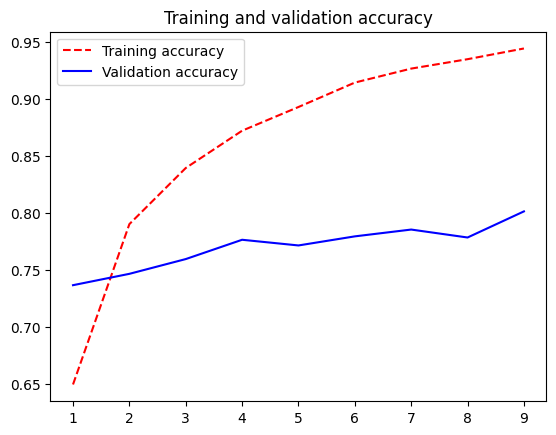

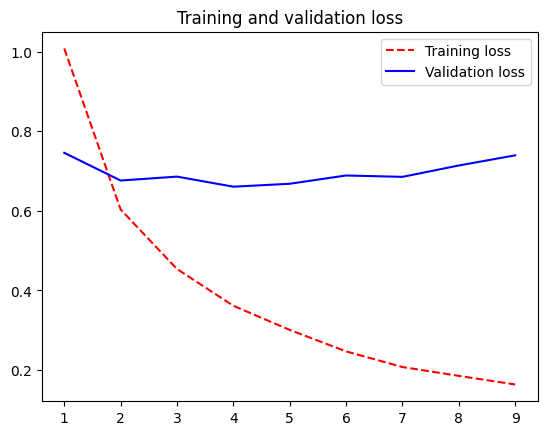

In [16]:
acc = mobilenet_history.history["accuracy"]
val_acc = mobilenet_history.history["val_accuracy"]
loss = mobilenet_history.history["loss"]
val_loss = mobilenet_history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [17]:
test_loss, test_acc = model.evaluate(test_dataset)
val_loss, val_acc = model.evaluate(val_dataset)
print("Test accuracy:", test_acc)
print("Validation accuracy:", val_acc)

16/16 [==============================] - 0s 21ms/step - loss: 0.6607 - accuracy: 0.7764
Test accuracy: 0.7507389187812805
Validation accuracy: 0.7764471173286438


In [18]:
# 1. Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

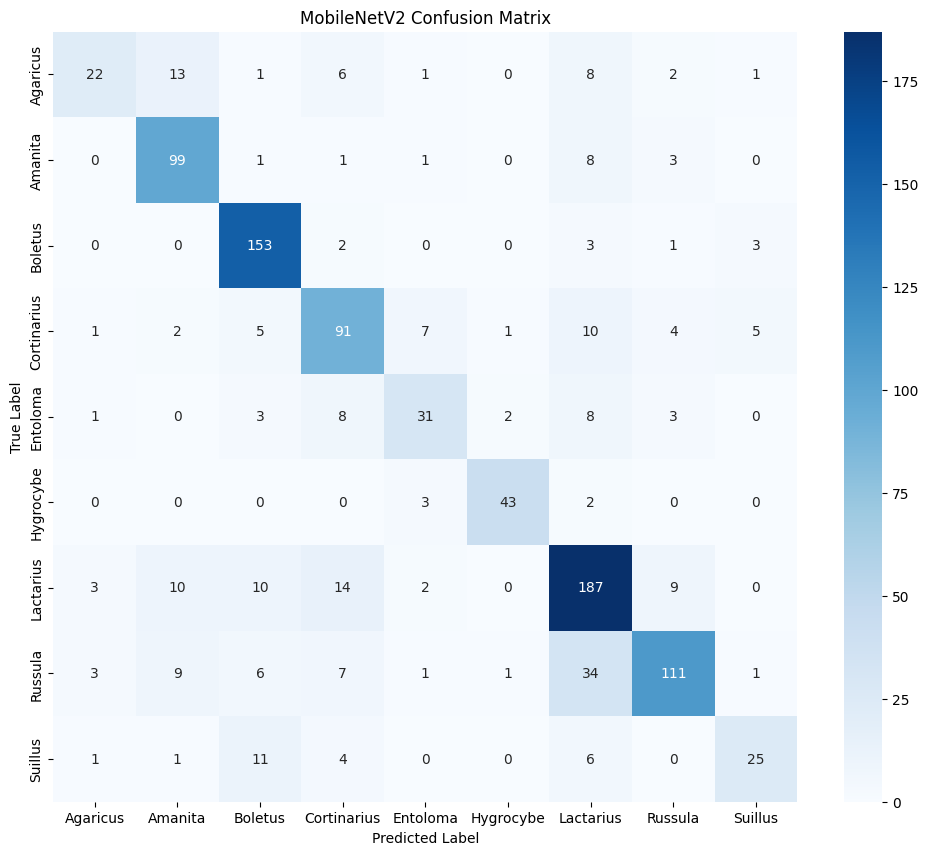

In [19]:
# 2. Create the matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot using Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('MobileNetV2 Confusion Matrix')
plt.show()

## MobileNetV2 Model (finetuned)

In [20]:
import tensorflow as tf
from keras.applications import MobileNetV2

conv_base = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# freeze all training
conv_base.trainable = False

In [21]:
from keras.optimizers import Adam
inputs = layers.Input(shape=(224, 224,3))
x = preprocess_input(inputs)
x = conv_base(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)
outputs = layers.Dense(num_classes, activation='softmax')(x)
model = keras.Model(inputs, outputs)

model.summary()

Model: "model_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_5 (InputLayer)        [(None, 224, 224, 3)]     0         
                                                                 
 tf.math.truediv_1 (TFOpLamb  (None, 224, 224, 3)      0         
 da)                                                             
                                                                 
 tf.math.subtract_1 (TFOpLam  (None, 224, 224, 3)      0         
 bda)                                                            
                                                                 
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 global_average_pooling2d_2   (None, 1280)             0         
 (GlobalAveragePooling2D)                                  

In [22]:
model.compile(optimizer=Adam(learning_rate=1e-3), loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [23]:
mobilenet_history = model.fit(
    train_dataset,
    batch_size=batch_size_n,
    epochs=5,
    validation_data=val_dataset,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/5
273/273 [==============================] - 8s 25ms/step - loss: 1.0007 - accuracy: 0.6507 - val_loss: 0.7437 - val_accuracy: 0.7365
Epoch 2/5
273/273 [==============================] - 6s 24ms/step - loss: 0.5934 - accuracy: 0.7920 - val_loss: 0.6594 - val_accuracy: 0.7635
Epoch 3/5
273/273 [==============================] - 6s 23ms/step - loss: 0.4510 - accuracy: 0.8445 - val_loss: 0.6624 - val_accuracy: 0.7605
Epoch 4/5
273/273 [==============================] - 6s 24ms/step - loss: 0.3532 - accuracy: 0.8752 - val_loss: 0.6504 - val_accuracy: 0.7735
Epoch 5/5
273/273 [==============================] - 6s 23ms/step - loss: 0.2921 - accuracy: 0.8985 - val_loss: 0.6787 - val_accuracy: 0.7705


In [24]:
conv_base.trainable = True

for layer in conv_base.layers[:-4]:
    layer.trainable = False
    
for layer in conv_base.layers[-4:]:
    layer.trainable = True

model.compile(optimizer=Adam(learning_rate=1e-5), loss='sparse_categorical_crossentropy', metrics=['accuracy'])    

In [25]:
from keras.callbacks import EarlyStopping

finetuned_history = model.fit(
    train_dataset,
    epochs=64,
    validation_data=val_dataset,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/64
273/273 [==============================] - 8s 26ms/step - loss: 0.2258 - accuracy: 0.9244 - val_loss: 0.6443 - val_accuracy: 0.7944
Epoch 2/64
273/273 [==============================] - 7s 24ms/step - loss: 0.1920 - accuracy: 0.9382 - val_loss: 0.6405 - val_accuracy: 0.7954
Epoch 3/64
273/273 [==============================] - 7s 24ms/step - loss: 0.1669 - accuracy: 0.9449 - val_loss: 0.6400 - val_accuracy: 0.7974
Epoch 4/64
273/273 [==============================] - 7s 24ms/step - loss: 0.1531 - accuracy: 0.9505 - val_loss: 0.6362 - val_accuracy: 0.8054
Epoch 5/64
273/273 [==============================] - 7s 24ms/step - loss: 0.1458 - accuracy: 0.9556 - val_loss: 0.6316 - val_accuracy: 0.8074
Epoch 6/64
273/273 [==============================] - 7s 24ms/step - loss: 0.1328 - accuracy: 0.9591 - val_loss: 0.6369 - val_accuracy: 0.8034
Epoch 7/64
273/273 [==============================] - 7s 24ms/step - loss: 0.1222 - accuracy: 0.9633 - val_loss: 0.6339 - val_accuracy: 0.8064

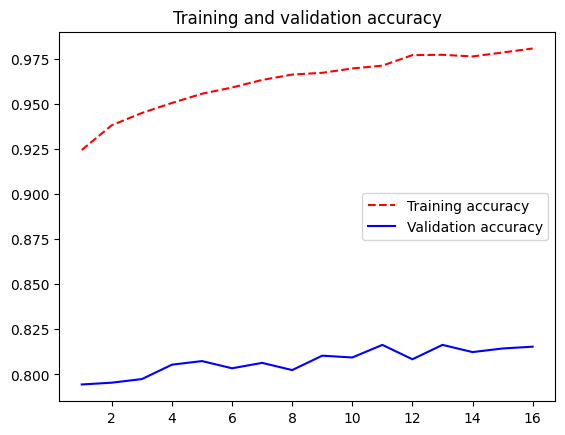

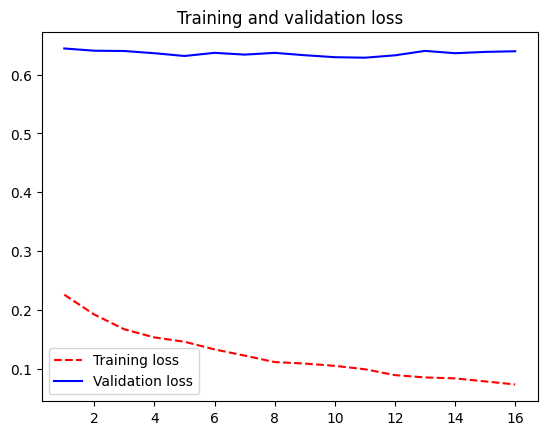

In [26]:
acc = finetuned_history.history["accuracy"]
val_acc = finetuned_history.history["val_accuracy"]
loss = finetuned_history.history["loss"]
val_loss = finetuned_history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [27]:
test_loss, test_acc = model.evaluate(test_dataset)
val_loss, val_acc = model.evaluate(val_dataset)
print("Test accuracy:", test_acc)
print("Validation accuracy:", val_acc)

16/16 [==============================] - 0s 21ms/step - loss: 0.6286 - accuracy: 0.8164
Test accuracy: 0.802955687046051
Validation accuracy: 0.8163672685623169


In [28]:
# 1. Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

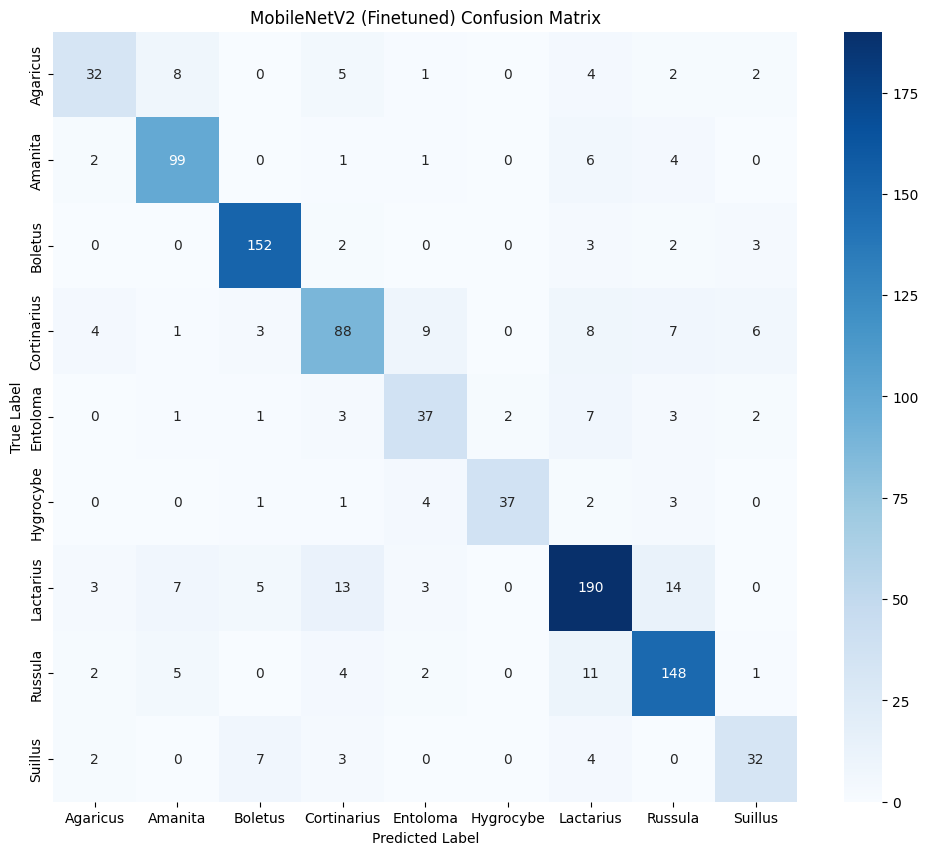

In [29]:
# 2. Create the matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot using Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('MobileNetV2 (Finetuned) Confusion Matrix')
plt.show()

## EfficientNet Model

In [31]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input as preprocess_input_eff

conv_base = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

conv_base.trainable = False

16705208/16705208 [==============================] - 1s 0us/step


In [32]:
inputs = keras.Input(shape=(224, 224, 3))
# EfficientNet preprocessing
x = preprocess_input_eff(inputs)

# Backbone
x = conv_base(x, training=False)

x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.5)(x)

outputs = layers.Dense(num_classes, activation='softmax')(x)

model = keras.Model(inputs, outputs)

In [36]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
eff_history = model.fit(
    train_dataset,
    batch_size=batch_size_n,
    epochs=5,
    validation_data=val_dataset,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/5
273/273 [==============================] - 14s 42ms/step - loss: 0.8143 - accuracy: 0.7245 - val_loss: 0.5506 - val_accuracy: 0.8194
Epoch 2/5
273/273 [==============================] - 10s 37ms/step - loss: 0.4188 - accuracy: 0.8555 - val_loss: 0.4852 - val_accuracy: 0.8273
Epoch 3/5
273/273 [==============================] - 10s 36ms/step - loss: 0.2994 - accuracy: 0.8983 - val_loss: 0.4694 - val_accuracy: 0.8483
Epoch 4/5
273/273 [==============================] - 10s 36ms/step - loss: 0.2297 - accuracy: 0.9236 - val_loss: 0.4490 - val_accuracy: 0.8553
Epoch 5/5
273/273 [==============================] - 10s 36ms/step - loss: 0.1822 - accuracy: 0.9393 - val_loss: 0.4694 - val_accuracy: 0.8453


In [38]:
conv_base.trainable = True

# Freeze early layers
for layer in conv_base.layers[:-20]:
    layer.trainable = False

In [39]:
model.compile(
    optimizer=keras.optimizers.Adam(1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [40]:
eff_history = model.fit(
    train_dataset,
    epochs=64,
    validation_data=val_dataset,
    callbacks=[
        EarlyStopping(patience=5, restore_best_weights=True)
    ]
)

Epoch 1/64
273/273 [==============================] - 14s 44ms/step - loss: 0.1236 - accuracy: 0.9631 - val_loss: 0.4090 - val_accuracy: 0.8752
Epoch 2/64
273/273 [==============================] - 11s 40ms/step - loss: 0.1013 - accuracy: 0.9681 - val_loss: 0.4096 - val_accuracy: 0.8723
Epoch 3/64
273/273 [==============================] - 11s 41ms/step - loss: 0.0858 - accuracy: 0.9758 - val_loss: 0.4042 - val_accuracy: 0.8792
Epoch 4/64
273/273 [==============================] - 11s 41ms/step - loss: 0.0716 - accuracy: 0.9794 - val_loss: 0.4036 - val_accuracy: 0.8812
Epoch 5/64
273/273 [==============================] - 11s 41ms/step - loss: 0.0651 - accuracy: 0.9817 - val_loss: 0.3985 - val_accuracy: 0.8862
Epoch 6/64
273/273 [==============================] - 11s 40ms/step - loss: 0.0574 - accuracy: 0.9846 - val_loss: 0.4018 - val_accuracy: 0.8842
Epoch 7/64
273/273 [==============================] - 11s 40ms/step - loss: 0.0526 - accuracy: 0.9857 - val_loss: 0.4020 - val_accuracy:

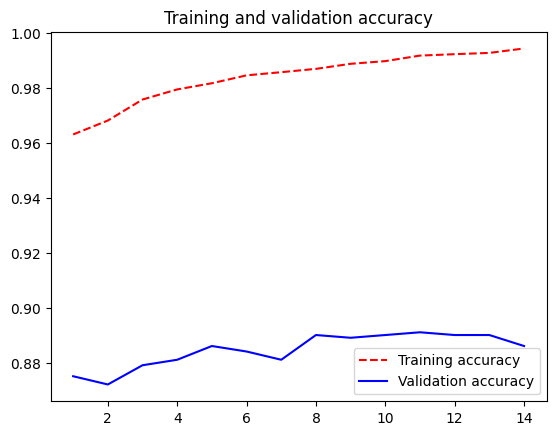

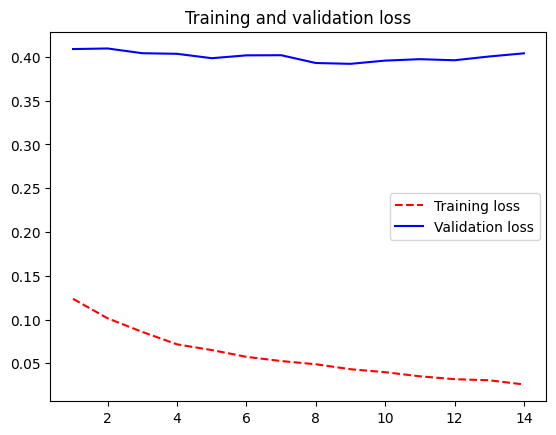

In [41]:
acc = eff_history.history["accuracy"]
val_acc = eff_history.history["val_accuracy"]
loss = eff_history.history["loss"]
val_loss = eff_history.history["val_loss"]
epochs = range(1, len(acc) + 1)
plt.plot(epochs, acc, "r--", label="Training accuracy")
plt.plot(epochs, val_acc, "b", label="Validation accuracy")
plt.title("Training and validation accuracy")
plt.legend()
plt.figure()
plt.plot(epochs, loss, "r--", label="Training loss")
plt.plot(epochs, val_loss, "b", label="Validation loss")
plt.title("Training and validation loss")
plt.legend()
plt.show()

In [42]:
test_loss, test_acc = model.evaluate(test_dataset)
val_loss, val_acc = model.evaluate(val_dataset)
print("Test accuracy:", test_acc)
print("Validation accuracy:", val_acc)

16/16 [==============================] - 1s 32ms/step - loss: 0.3921 - accuracy: 0.8892
Test accuracy: 0.8886699676513672
Validation accuracy: 0.8892215490341187


In [43]:
# 1. Get true labels and predictions
y_true = []
y_pred = []

for images, labels in test_dataset:
    preds = model.predict(images, verbose=0)
    y_true.extend(labels.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

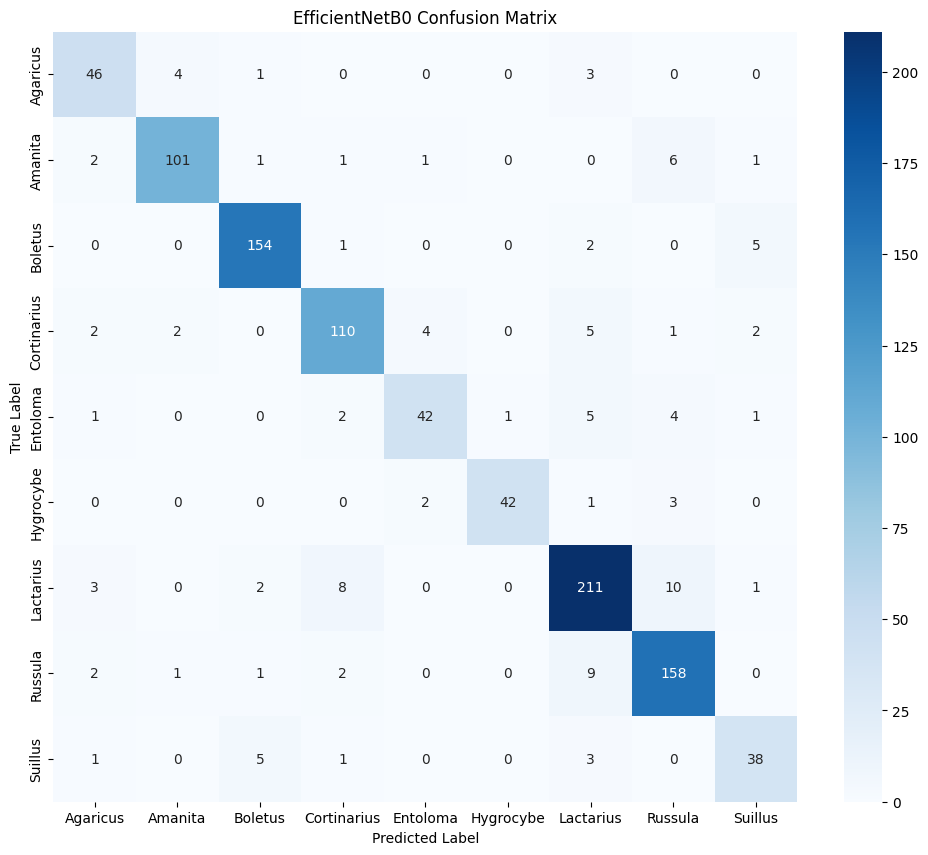

In [45]:
# 2. Create the matrix
cm = confusion_matrix(y_true, y_pred)

# 3. Plot using Seaborn
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, 
            yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('EfficientNetB0 Confusion Matrix')
plt.show()